This notebook contains all the code needed to reproduce figure 2 (a comparison of parameterized precip. for ZMS-DEF and ZM-DEF). 

In [1]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

from ep_processing import *
from utils.visualization import * 

# Plotting stuff
TITLE_FONT_SIZE = 15
TICK_FONT_SIZE = 12

plt.rc('axes', labelsize = TITLE_FONT_SIZE)
plt.rc('xtick', labelsize = TICK_FONT_SIZE)   
plt.rc('ytick', labelsize = TICK_FONT_SIZE)

In [2]:
my_experiment_name = "amip"
my_zms_runid = "agm-amip-test"
my_zm_runid = "agm-diagn-cc-amip"

# Some example paths if you're running of Trillium instead...
# my_base_path = "/scratch/<YOUR-USERNAME>/canesm_runs/{runid}/data/nc_output/CMIP6/CMIP/CP4C/CanESM5-1/{experiment_name}/r1i1p1f1/"
# my_daily_path = "day/{var_name}/gn/v20190429/{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

# Change these accordingly based on where you are storing the data
my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_file_path = "{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [3]:
da_epr_zms, da_eprc_zms, da_eprr_zms = get_ep_info(
    my_zms_runid,
    my_experiment_name,
    year_range,
    base_path = my_base_path,
    file_path = my_file_path,
)

da_epr_mean_zms = da_epr_zms.mean(dim = "time")
da_eprc_mean_zms = da_eprc_zms.mean(dim = "time")
da_eprr_mean_zms = da_eprr_zms.mean(dim = "time")

In [4]:
da_epr_zm, da_eprc_zm, da_eprr_zm = get_ep_info(
    my_zm_runid,
    my_experiment_name,
    year_range,
    base_path = my_base_path,
    file_path = my_file_path,
)

da_epr_mean_zm = da_epr_zm.mean(dim = "time")
da_eprc_mean_zm = da_eprc_zm.mean(dim = "time")
da_eprr_mean_zm = da_eprr_zm.mean(dim = "time")

Let's look at the differences between the maximum parameterized precip. produced by ZMS-DEF and ZM-DEF. 

In [5]:
da_eprc_max_zms = da_eprc_mean_zms.max().values
da_eprc_max_zm = da_eprc_mean_zm.max().values

print("ZMS-DEF max. parameterized precip = ", da_eprc_max_zms)
print("ZM-DEF max. parameterized precip = ", da_eprc_max_zm)

ZMS-DEF max. parameterized precip =  26.51500129699707
ZM-DEF max. parameterized precip =  25.14918327331543


In [6]:
da_eprc_max_zms - da_eprc_max_zm

np.float64(1.3658180236816406)

In [7]:
da_epr_max = max(
    da_eprc_max_zms,
    da_eprc_max_zm
)

Running this code box will reproduce fig. 2. 

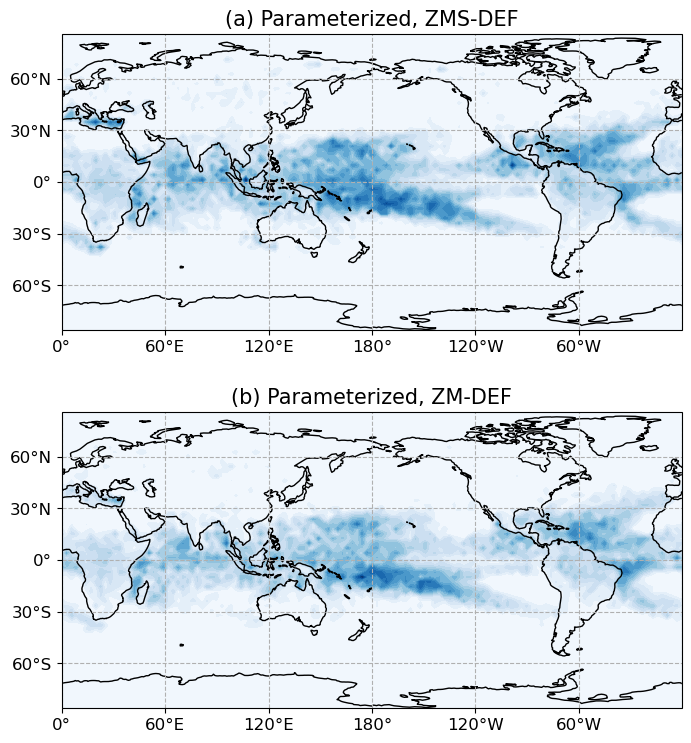

In [8]:
# Define some key vars used throughout the plotting
projection = ccrs.PlateCarree(central_longitude = 180)
ytickdelta = 30
xtickdelta = 60
levels = 16
vmin = 0.
vmax = da_epr_max
my_bbox = [-180, 180, -86, 86]
my_levels = np.linspace(vmin, vmax, levels + 1, endpoint=True)

# Instantiate the figure with axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), subplot_kw={"projection": projection})

# Collect data and labels
da_list = [
    da_eprc_mean_zms, 
    da_eprc_mean_zm,
]

label_list = [
    "(a) Parameterized, ZMS-DEF",
    "(b) Parameterized, ZM-DEF",
]

# Now create the figures by working "axes by axes"
for (ax, da, label) in zip((ax1, ax2), da_list, label_list):

    # Draw grid lines & features on axes
    ax.set_global()
    ax.coastlines()

    gl = ax.gridlines(draw_labels = True, crs = projection, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = False

    # Tick labels of lat/lon thanks to this nice post:
    # https://stackoverflow.com/questions/61577057/weird-setting-of-latitude-labels-in-cartopy-miller-projection
    ax.set_yticks(np.arange(-90, 90.5, ytickdelta), crs = ccrs.PlateCarree())
    lat_formatter = LatitudeFormatter()
    ax.yaxis.set_major_formatter(lat_formatter)     

    ax.set_xticks(np.arange(-180, 180, xtickdelta), crs = ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)

    # Make the filled contour plot
    field_vals, lon_plt, lat_plt = process_for_map(da)

    co = ax.contourf(
                lon_plt,
                lat_plt,
                field_vals,
                transform = ccrs.PlateCarree(),
                levels = my_levels,
                cmap = "Blues",
                vmin = vmin,
                vmax = vmax,
    )
    
    # Create title
    ax.set_title(label, fontsize = TITLE_FONT_SIZE)

    # Clip the poles 
    ax.set_extent(my_bbox, crs=ccrs.PlateCarree())

    # Make the colorbar on the final plot 
    if label == "Parameterized, ZM-DEF":
        cbar_ax = fig.add_axes([0.95, 0.12, 0.05, 0.33])
        cbar = plt.colorbar(co, cax = cbar_ax)
        cbar.ax.tick_params(labelsize = TICK_FONT_SIZE)
        cbar.set_label(r"Precip. Intensity (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
        cbar.mappable.set_clim(vmin, vmax)

# Uncomment to save the figure. 
# plt.savefig(
#     "images/" + "ZMS-vs-ZM-param-compare",
#     dpi = 600,
#     bbox_inches = "tight",
# )

plt.show()